## Classification for Breast Cancer

##### Before the beginning, important to download data from kaggle: 
##### - jpeg (zip - 5 Go)
##### - mass_case_description_train_set.csv
##### - mass_case_description_test_set.csv

In [223]:
import pandas as pd

data = pd.read_csv("mass_case_description_train_set.csv")
print(data.shape)
print(data.info())
print(type(data))
data.head()

In [8]:
print(data["image file path"][0])
print(data["image file path"][12])

Mass-Training_P_00001_LEFT_CC/1.3.6.1.4.1.9590.100.1.2.422112722213189649807611434612228974994/1.3.6.1.4.1.9590.100.1.2.342386194811267636608694132590482924515/000000.dcm
Mass-Training_P_00021_RIGHT_CC/1.3.6.1.4.1.9590.100.1.2.114376984313241513706470829062391344750/1.3.6.1.4.1.9590.100.1.2.238517328812179290330581800221092807231/000000.dcm


In [7]:
path_test = data["image file path"][0]
folders = path_test.split("/")
print(folders)

['Mass-Training_P_00001_LEFT_CC', '1.3.6.1.4.1.9590.100.1.2.422112722213189649807611434612228974994', '1.3.6.1.4.1.9590.100.1.2.342386194811267636608694132590482924515', '000000.dcm']


#### we want to extract folders[2] because folders[1] doesn't exist in our images

In [21]:
all_paths = data["image file path"]
folders_used = []
for path in all_paths:
    fold = path.split("/")
    folders_used.append(fold[2])

In [22]:
print(len(folders_used))

1318


In [25]:
print(len(set(folders_used)))

1231


## See that we have repetitions in data

In [52]:
print(type(data))
data_duplicates = data[data["image file path"].duplicated()]
data_duplicates

<class 'pandas.core.frame.DataFrame'>


,patient_id,breast_density,left or right breast,image view,abnormality id,abnormality type,mass shape,mass margins,assessment,pathology,subtlety,image file path,cropped image file path,ROI mask file path
27,P_00044,2,RIGHT,CC,2,mass,OVAL,CIRCUMSCRIBED,3,BENIGN,5,Mass-Training_P_00044_RIGHT_CC/1.3.6.1.4.1.959...,Mass-Training_P_00044_RIGHT_CC_2/1.3.6.1.4.1.9...,Mass-Training_P_00044_RIGHT_CC_2/1.3.6.1.4.1.9...
28,P_00044,2,RIGHT,CC,3,mass,OVAL,CIRCUMSCRIBED,3,BENIGN,5,Mass-Training_P_00044_RIGHT_CC/1.3.6.1.4.1.959...,Mass-Training_P_00044_RIGHT_CC_3/1.3.6.1.4.1.9...,Mass-Training_P_00044_RIGHT_CC_3/1.3.6.1.4.1.9...
29,P_00044,2,RIGHT,CC,4,mass,LOBULATED,CIRCUMSCRIBED,3,BENIGN,5,Mass-Training_P_00044_RIGHT_CC/1.3.6.1.4.1.959...,Mass-Training_P_00044_RIGHT_CC_4/1.3.6.1.4.1.9...,Mass-Training_P_00044_RIGHT_CC_4/1.3.6.1.4.1.9...
31,P_00044,2,RIGHT,MLO,2,mass,OVAL,CIRCUMSCRIBED,3,BENIGN,5,Mass-Training_P_00044_RIGHT_MLO/1.3.6.1.4.1.95...,Mass-Training_P_00044_RIGHT_MLO_2/1.3.6.1.4.1....,Mass-Training_P_00044_RIGHT_MLO_2/1.3.6.1.4.1....
68,P_00092,2,LEFT,MLO,2,mass,ROUND,CIRCUMSCRIBED,4,MALIGNANT,5,Mass-Training_P_00092_LEFT_MLO/1.3.6.1.4.1.959...,Mass-Training_P_00092_LEFT_MLO_2/1.3.6.1.4.1.9...,Mass-Training_P_00092_LEFT_MLO_2/1.3.6.1.4.1.9...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1121,P_01632,1,LEFT,CC,2,mass,LYMPH_NODE,CIRCUMSCRIBED,3,BENIGN_WITHOUT_CALLBACK,2,Mass-Training_P_01632_LEFT_CC/1.3.6.1.4.1.9590...,Mass-Training_P_01632_LEFT_CC_2/1.3.6.1.4.1.95...,Mass-Training_P_01632_LEFT_CC_2/1.3.6.1.4.1.95...
1123,P_01632,1,LEFT,MLO,2,mass,LYMPH_NODE,CIRCUMSCRIBED,3,BENIGN_WITHOUT_CALLBACK,2,Mass-Training_P_01632_LEFT_MLO/1.3.6.1.4.1.959...,Mass-Training_P_01632_LEFT_MLO_2/1.3.6.1.4.1.9...,Mass-Training_P_01632_LEFT_MLO_2/1.3.6.1.4.1.9...
1157,P_01656,2,LEFT,CC,2,mass,IRREGULAR,ILL_DEFINED,5,MALIGNANT,4,Mass-Training_P_01656_LEFT_CC/1.3.6.1.4.1.9590...,Mass-Training_P_01656_LEFT_CC_2/1.3.6.1.4.1.95...,Mass-Training_P_01656_LEFT_CC_2/1.3.6.1.4.1.95...
1159,P_01656,2,LEFT,MLO,2,mass,LOBULATED,ILL_DEFINED,4,MALIGNANT,4,Mass-Training_P_01656_LEFT_MLO/1.3.6.1.4.1.959...,Mass-Training_P_01656_LEFT_MLO_2/1.3.6.1.4.1.9...,Mass-Training_P_01656_LEFT_MLO_2/1.3.6.1.4.1.9...


##### 1318 - 87 = 1231 unique values

In [55]:
data_without_duplicates = data.drop_duplicates(subset=["image file path"])
data_without_duplicates

,patient_id,breast_density,left or right breast,image view,abnormality id,abnormality type,mass shape,mass margins,assessment,pathology,subtlety,image file path,cropped image file path,ROI mask file path
0,P_00001,3,LEFT,CC,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4,Mass-Training_P_00001_LEFT_CC/1.3.6.1.4.1.9590...,Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.95...,Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.95...
1,P_00001,3,LEFT,MLO,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4,Mass-Training_P_00001_LEFT_MLO/1.3.6.1.4.1.959...,Mass-Training_P_00001_LEFT_MLO_1/1.3.6.1.4.1.9...,Mass-Training_P_00001_LEFT_MLO_1/1.3.6.1.4.1.9...
2,P_00004,3,LEFT,CC,1,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,4,BENIGN,3,Mass-Training_P_00004_LEFT_CC/1.3.6.1.4.1.9590...,Mass-Training_P_00004_LEFT_CC_1/1.3.6.1.4.1.95...,Mass-Training_P_00004_LEFT_CC_1/1.3.6.1.4.1.95...
3,P_00004,3,LEFT,MLO,1,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,4,BENIGN,3,Mass-Training_P_00004_LEFT_MLO/1.3.6.1.4.1.959...,Mass-Training_P_00004_LEFT_MLO_1/1.3.6.1.4.1.9...,Mass-Training_P_00004_LEFT_MLO_1/1.3.6.1.4.1.9...
4,P_00004,3,RIGHT,MLO,1,mass,OVAL,CIRCUMSCRIBED,4,BENIGN,5,Mass-Training_P_00004_RIGHT_MLO/1.3.6.1.4.1.95...,Mass-Training_P_00004_RIGHT_MLO_1/1.3.6.1.4.1....,Mass-Training_P_00004_RIGHT_MLO_1/1.3.6.1.4.1....
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1313,P_02033,2,RIGHT,MLO,1,mass,IRREGULAR,ILL_DEFINED,3,MALIGNANT,4,Mass-Training_P_02033_RIGHT_MLO/1.3.6.1.4.1.95...,Mass-Training_P_02033_RIGHT_MLO_1/1.3.6.1.4.1....,Mass-Training_P_02033_RIGHT_MLO_1/1.3.6.1.4.1....
1314,P_02079,2,RIGHT,CC,1,mass,ROUND,SPICULATED,3,MALIGNANT,5,Mass-Training_P_02079_RIGHT_CC/1.3.6.1.4.1.959...,Mass-Training_P_02079_RIGHT_CC_1/1.3.6.1.4.1.9...,Mass-Training_P_02079_RIGHT_CC_1/1.3.6.1.4.1.9...
1315,P_02079,2,RIGHT,MLO,1,mass,ROUND,SPICULATED,3,MALIGNANT,5,Mass-Training_P_02079_RIGHT_MLO/1.3.6.1.4.1.95...,Mass-Training_P_02079_RIGHT_MLO_1/1.3.6.1.4.1....,Mass-Training_P_02079_RIGHT_MLO_1/1.3.6.1.4.1....
1316,P_02092,2,LEFT,CC,1,mass,IRREGULAR,SPICULATED,3,MALIGNANT,2,Mass-Training_P_02092_LEFT_CC/1.3.6.1.4.1.9590...,Mass-Training_P_02092_LEFT_CC_1/1.3.6.1.4.1.95...,Mass-Training_P_02092_LEFT_CC_1/1.3.6.1.4.1.95...


### We will now work with our 1231 folders (i.e 1231 images)
#### Stroring in X_train and y_train the data and the labels

In [63]:
import os
from PIL import Image
import numpy as np

In [116]:
X_train_list = []
y_train_list = data_without_duplicates["pathology"]
y_train = np.array(y_train_list)
print(y_train.shape) #(1231,)

folder = "0_Images"
#folders_used_without_duplicates = set(folders_used)
all_p = data_without_duplicates["image file path"]
folders_used_without_duplicates = []
for p in all_p:
    fold = p.split("/")
    folders_used_without_duplicates.append(fold[2])

#print(folders_used_without_duplicates)

for fold in os.listdir(folder):
    if fold in folders_used_without_duplicates:
        img_path = os.path.join(folder, fold)
        for file in os.listdir(img_path):
            if file.lower().endswith((".jpg", ".jpeg")):
                final_path = os.path.join(img_path, file)
                img = Image.open(final_path).convert("L")
                img = img.resize((128, 128))
                img_array = np.array(img)/255
                X_train_list.append(img_array)
                #print("im", img_array.shape)  #(128,128)
                #print("Image ouverte :", final_path)

X_train = np.stack(X_train_list, axis=0)
print(X_train.shape) #(1231, 128, 128)
#run time = 1min30

(1231,)
(1231, 128, 128)


##### in the y_train, we now need to regroup benign and benign_without_callback

In [312]:
y_train_list = data_without_duplicates["pathology"]
y_train = np.array(y_train_list)
print(y_train.shape) #(1231,)

(1231,)


In [313]:
for y in range(len(y_train)):
    if y_train[y].startswith("BENIGN"):
        y_train[y] = 1
    else:
        y_train[y] = 0

In [314]:
print(y_train)
y_train = np.array(y_train, dtype=np.int64)  # CONVERSION TO RIGHT TYPE FOR TENSOR
print(type(y_train[0]))

[0 0 1 ... 0 0 0]
<class 'numpy.int64'>


In [315]:
import matplotlib.pyplot as plt

(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

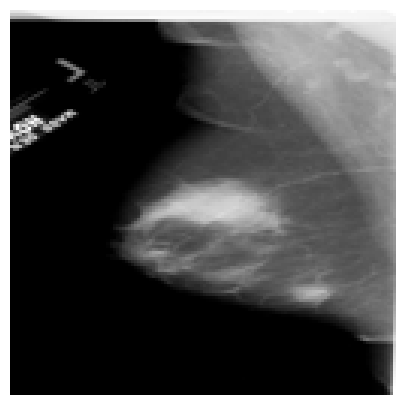

In [316]:
fig, axes = plt.subplots(1, 1, figsize = (10, 5))

axes.imshow(img_array, cmap = "gray")
axes.axis("off")

In [128]:
!pip install torch
import torch


[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/114.6 MB ? eta -:--:--
   ---------------------------------------- 0.4/114.6 MB 7.4 MB/s eta 0:00:16
   ---------------------------------------- 1.2/114.6 MB 15.8 MB/s eta 0:00:08
    --------------------------------------- 2.1/114.6 MB 19.1 MB/s eta 0:00:06
   - -------------------------------------- 3.1/114.6 MB 18.0 MB/s eta 0:00:07
   - -------------------------------------- 4.3/114.6 MB 21.2 MB/s eta 0:00:06
   - -------------------------------------- 5.1/114.6 MB 20.4 MB/s eta 0:00:06
   -- ------------------------------------- 6.4/114.6 MB 22.7 MB/s eta 0:00:05
   -- ------------------------------------- 7.2/114.6 MB 21.9 MB/s eta 0:00:05
   -- ------------------------------------- 8.4/114.6 MB 22.4 MB/s eta 0:00:05
   --- ------------------------------------ 9.5/114.6 MB 22.6 MB/s eta 0:00:05
   --- ------------------------------------ 10.6/114.6 MB 25.2 MB/s eta 0:00:05
   --- ------------------------------------ 11.0/114.6 MB 23

In [317]:
X = torch.tensor(X_train, dtype=torch.float32)
y = torch.tensor(y_train, dtype=torch.long)

X = X.view(-1, 1, 128, 128)

#X = torch.mean(X, dim=1, keepdim=True)  # (1231, 1, 128, 128)

print("Shape finale X:", X.shape) #(1231, 1, 128, 128)

Shape finale X: torch.Size([1231, 1, 128, 128])


In [318]:
from torch.utils.data import DataLoader, TensorDataset

In [319]:
dataset = TensorDataset(X, y)
train_loader = DataLoader(dataset, batch_size=64, shuffle=True)

In [320]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [321]:
class BinaryCNN(nn.Module):
    def __init__(self):
        super(BinaryCNN, self).__init__()

        # 🔹 Convolutions
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)

        # 128 → 64 → 32 → 16
        self.fc1 = nn.Linear(64 * 16 * 16, 128)
        
        self.fc2 = nn.Linear(128, 1)

        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # 64x64
        x = self.pool(F.relu(self.conv2(x)))  # 32x32
        x = self.pool(F.relu(self.conv3(x)))  # 16x16

        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = self.dropout(x)

        x = self.fc2(x)

        return x  # pas de sigmoid ici

In [322]:
import torch.optim as optim

In [323]:
model = BinaryCNN()

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [324]:
model.train()

BinaryCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=16384, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=1, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)

## Formulas 

Recall = TP/(TP+FN)  = True Positive / All Positives
<br>
Precision = TP/(TP+FP) = True Positive / Predicted Positives

In [371]:
epochs = 10
correct = 0
total = 0

# positive = with label 0 (= MALIGNANT) (sorry not logic)
true_positive = 0   # -> label = 0; predicted = 0
false_positive = 0  # -> label = 1; predicted = 0
false_negative = 0  # -> label = 0; predicted = 1

for epoch in range(epochs):
    running_loss = 0.0
        

    for images, labels in train_loader:
        optimizer.zero_grad()

        labels = labels.float().unsqueeze(1)   # (batch, 1)

        outputs = model(images)                # (batch, 1)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        predicted = (torch.sigmoid(outputs) > 0.5).long()

        # computation of true & false positive/negative
        pred = predicted.view(-1)
        true_label = labels.view(-1).long()
        
        true_positive += ((pred == 0) & (true_label == 0)).sum().item()
        false_positive += ((pred == 0) & (true_label == 1)).sum().item()
        false_negative += ((pred == 1) & (true_label == 0)).sum().item()

        #total += labels.size(0)
        #correct += (predicted == labels.long()).sum().item()

    print(f"Epoch {epoch+1}/{epochs} - Loss: {running_loss:.4f}")
    recall = 100 * (true_positive/(true_positive + false_negative))
    precision = 100 * (true_positive/(true_positive + false_positive))
    print(f"Recall: {recall:.2f}%")
    print(f"Precision: {precision:.2f}%")

recall = 100 * (true_positive/(true_positive + false_negative))
precision = 100 * (true_positive/(true_positive + false_positive))
print(f"Training  Recall: {recall:.2f}%")
print(f"Training  Precision: {precision:.2f}%")

Epoch 1/10 - Loss: 10.5893
Recall: 69.35%
Precision: 72.50%
Epoch 2/10 - Loss: 9.5732
Recall: 73.28%
Precision: 74.22%
Epoch 3/10 - Loss: 8.3928
Recall: 74.54%
Precision: 76.64%
Epoch 4/10 - Loss: 7.2930
Recall: 77.01%
Precision: 78.52%
Epoch 5/10 - Loss: 5.5137
Recall: 79.03%
Precision: 80.35%
Epoch 6/10 - Loss: 4.1458
Recall: 81.41%
Precision: 82.49%
Epoch 7/10 - Loss: 3.3473
Recall: 83.27%
Precision: 84.06%
Epoch 8/10 - Loss: 2.2053
Recall: 85.01%
Precision: 85.60%
Epoch 9/10 - Loss: 1.3487
Recall: 86.51%
Precision: 87.01%
Epoch 10/10 - Loss: 1.2174
Recall: 87.71%
Precision: 88.15%
Training  Recall: 87.71%
Training  Precision: 88.15%


### Delete Model to restart from beginning
##### Running time model(10 loops) = 2min

In [311]:
del model
del optimizer

## Test Data

### Preprocessing

In [382]:
data_test = pd.read_csv("mass_case_description_test_set.csv")
print(data_test.shape)
print(data_test.info())
data_test.head()

(378, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 378 entries, 0 to 377
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   patient_id               378 non-null    object
 1   breast_density           378 non-null    int64 
 2   left or right breast     378 non-null    object
 3   image view               378 non-null    object
 4   abnormality id           378 non-null    int64 
 5   abnormality type         378 non-null    object
 6   mass shape               378 non-null    object
 7   mass margins             361 non-null    object
 8   assessment               378 non-null    int64 
 9   pathology                378 non-null    object
 10  subtlety                 378 non-null    int64 
 11  image file path          378 non-null    object
 12  cropped image file path  378 non-null    object
 13  ROI mask file path       378 non-null    object
dtypes: int64(4), object(10)
memory u

,patient_id,breast_density,left or right breast,image view,abnormality id,abnormality type,mass shape,mass margins,assessment,pathology,subtlety,image file path,cropped image file path,ROI mask file path
0,P_00016,4,LEFT,CC,1,mass,IRREGULAR,SPICULATED,5,MALIGNANT,5,Mass-Test_P_00016_LEFT_CC/1.3.6.1.4.1.9590.100...,Mass-Test_P_00016_LEFT_CC_1/1.3.6.1.4.1.9590.1...,Mass-Test_P_00016_LEFT_CC_1/1.3.6.1.4.1.9590.1...
1,P_00016,4,LEFT,MLO,1,mass,IRREGULAR,SPICULATED,5,MALIGNANT,5,Mass-Test_P_00016_LEFT_MLO/1.3.6.1.4.1.9590.10...,Mass-Test_P_00016_LEFT_MLO_1/1.3.6.1.4.1.9590....,Mass-Test_P_00016_LEFT_MLO_1/1.3.6.1.4.1.9590....
2,P_00017,2,LEFT,CC,1,mass,ROUND,CIRCUMSCRIBED,4,MALIGNANT,4,Mass-Test_P_00017_LEFT_CC/1.3.6.1.4.1.9590.100...,Mass-Test_P_00017_LEFT_CC_1/1.3.6.1.4.1.9590.1...,Mass-Test_P_00017_LEFT_CC_1/1.3.6.1.4.1.9590.1...
3,P_00017,2,LEFT,MLO,1,mass,ROUND,ILL_DEFINED,4,MALIGNANT,4,Mass-Test_P_00017_LEFT_MLO/1.3.6.1.4.1.9590.10...,Mass-Test_P_00017_LEFT_MLO_1/1.3.6.1.4.1.9590....,Mass-Test_P_00017_LEFT_MLO_1/1.3.6.1.4.1.9590....
4,P_00032,3,RIGHT,CC,1,mass,ROUND,OBSCURED,0,BENIGN,2,Mass-Test_P_00032_RIGHT_CC/1.3.6.1.4.1.9590.10...,Mass-Test_P_00032_RIGHT_CC_1/1.3.6.1.4.1.9590....,Mass-Test_P_00032_RIGHT_CC_1/1.3.6.1.4.1.9590....


In [383]:
all_paths_test = data_test["image file path"]
folders_used_test = []
for path_test in all_paths_test:
    fold_test = path_test.split("/")
    folders_used_test.append(fold_test[2])

In [384]:
print(len(folders_used_test))
print(len(set(folders_used_test)))

378
361


##### 378 - 361 = 15 doublons

In [385]:
data_test_without_duplicates = data_test.drop_duplicates(subset=["image file path"])
data_test_without_duplicates

,patient_id,breast_density,left or right breast,image view,abnormality id,abnormality type,mass shape,mass margins,assessment,pathology,subtlety,image file path,cropped image file path,ROI mask file path
0,P_00016,4,LEFT,CC,1,mass,IRREGULAR,SPICULATED,5,MALIGNANT,5,Mass-Test_P_00016_LEFT_CC/1.3.6.1.4.1.9590.100...,Mass-Test_P_00016_LEFT_CC_1/1.3.6.1.4.1.9590.1...,Mass-Test_P_00016_LEFT_CC_1/1.3.6.1.4.1.9590.1...
1,P_00016,4,LEFT,MLO,1,mass,IRREGULAR,SPICULATED,5,MALIGNANT,5,Mass-Test_P_00016_LEFT_MLO/1.3.6.1.4.1.9590.10...,Mass-Test_P_00016_LEFT_MLO_1/1.3.6.1.4.1.9590....,Mass-Test_P_00016_LEFT_MLO_1/1.3.6.1.4.1.9590....
2,P_00017,2,LEFT,CC,1,mass,ROUND,CIRCUMSCRIBED,4,MALIGNANT,4,Mass-Test_P_00017_LEFT_CC/1.3.6.1.4.1.9590.100...,Mass-Test_P_00017_LEFT_CC_1/1.3.6.1.4.1.9590.1...,Mass-Test_P_00017_LEFT_CC_1/1.3.6.1.4.1.9590.1...
3,P_00017,2,LEFT,MLO,1,mass,ROUND,ILL_DEFINED,4,MALIGNANT,4,Mass-Test_P_00017_LEFT_MLO/1.3.6.1.4.1.9590.10...,Mass-Test_P_00017_LEFT_MLO_1/1.3.6.1.4.1.9590....,Mass-Test_P_00017_LEFT_MLO_1/1.3.6.1.4.1.9590....
4,P_00032,3,RIGHT,CC,1,mass,ROUND,OBSCURED,0,BENIGN,2,Mass-Test_P_00032_RIGHT_CC/1.3.6.1.4.1.9590.10...,Mass-Test_P_00032_RIGHT_CC_1/1.3.6.1.4.1.9590....,Mass-Test_P_00032_RIGHT_CC_1/1.3.6.1.4.1.9590....
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
373,P_01825,2,RIGHT,MLO,1,mass,LOBULATED,MICROLOBULATED,3,BENIGN_WITHOUT_CALLBACK,3,Mass-Test_P_01825_RIGHT_MLO/1.3.6.1.4.1.9590.1...,Mass-Test_P_01825_RIGHT_MLO_1/1.3.6.1.4.1.9590...,Mass-Test_P_01825_RIGHT_MLO_1/1.3.6.1.4.1.9590...
374,P_01833,2,RIGHT,MLO,1,mass,IRREGULAR,ILL_DEFINED,5,MALIGNANT,5,Mass-Test_P_01833_RIGHT_MLO/1.3.6.1.4.1.9590.1...,Mass-Test_P_01833_RIGHT_MLO_1/1.3.6.1.4.1.9590...,Mass-Test_P_01833_RIGHT_MLO_1/1.3.6.1.4.1.9590...
375,P_01865,2,LEFT,MLO,1,mass,IRREGULAR,ILL_DEFINED,4,MALIGNANT,2,Mass-Test_P_01865_LEFT_MLO/1.3.6.1.4.1.9590.10...,Mass-Test_P_01865_LEFT_MLO_1/1.3.6.1.4.1.9590....,Mass-Test_P_01865_LEFT_MLO_1/1.3.6.1.4.1.9590....
376,P_01912,3,RIGHT,CC,1,mass,IRREGULAR,SPICULATED,5,MALIGNANT,4,Mass-Test_P_01912_RIGHT_CC/1.3.6.1.4.1.9590.10...,Mass-Test_P_01912_RIGHT_CC_1/1.3.6.1.4.1.9590....,Mass-Test_P_01912_RIGHT_CC_1/1.3.6.1.4.1.9590....


### Resizing

In [386]:
X_test_list = []
y_test_list = data_test_without_duplicates["pathology"]
y_test = np.array(y_test_list)
print(y_test.shape) #(361,)

folder_test = "0_Images"
#folders_used_without_duplicates = set(folders_used)
all_p_test = data_test_without_duplicates["image file path"]
folders_test_used_without_duplicates = []
for p_test in all_p_test:
    fold_test = p_test.split("/")
    folders_test_used_without_duplicates.append(fold_test[2])

#print(folders_used_without_duplicates)

for fold_test in os.listdir(folder_test):
    if fold_test in folders_test_used_without_duplicates:
        img_test_path = os.path.join(folder_test, fold_test)
        for file_test in os.listdir(img_test_path):
            if file_test.lower().endswith((".jpg", ".jpeg")):
                final_test_path = os.path.join(img_test_path, file_test)
                img_test = Image.open(final_test_path).convert("L")
                img_test = img_test.resize((128, 128))
                img_test_array = np.array(img_test)/255
                X_test_list.append(img_test_array)
                #print("im", img_array.shape)  #(128,128)
                #print("Image ouverte :", final_path)

X_test = np.stack(X_test_list, axis=0)
print(X_test.shape) #(361, 128, 128)
#run time = 1min

(361,)
(361, 128, 128)


In [387]:
y_test_list = data_test_without_duplicates["pathology"]
y_test = np.array(y_test_list)
print(y_test.shape) #(361,)

(361,)


In [388]:
for y in range(len(y_test)):
    if y_test[y].startswith("BENIGN"):
        y_test[y] = 1
    else:
        y_test[y] = 0
print(y_test)
y_test = np.array(y_test, dtype=np.int64)  # CONVERSION TO RIGHT TYPE FOR TENSOR
print(type(y_test[0]))

[0 0 0 0 1 1 0 0 1 0 0 1 1 0 0 0 0 1 1 1 1 1 1 1 0 0 1 1 1 1 1 1 1 1 1 1 1
 1 0 0 0 0 1 1 1 1 0 0 1 1 0 0 0 1 1 1 1 1 1 0 0 0 0 1 1 1 1 1 0 0 1 1 1 1
 1 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 1 1
 0 0 0 1 1 0 0 0 0 0 1 1 0 0 0 0 1 1 0 0 0 1 1 1 1 1 1 1 1 1 0 0 1 0 0 1 0
 1 1 1 1 0 0 1 1 1 1 1 1 1 0 0 0 0 1 1 0 0 1 0 0 0 1 1 1 1 0 0 1 1 1 1 1 1
 1 1 1 0 0 0 0 1 0 0 0 0 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 0 0
 0 0 0 0 1 0 1 1 1 1 1 0 0 0 0 0 0 1 1 1 1 1 1 0 0 0 0 0 0 1 1 1 1 1 1 0 0
 1 1 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 0 1 0 1 1 1 1 1 1 1 1 0 0 1 1 0 0 1 1
 0 0 1 1 1 1 1 1 1 1 1 1 1 0 0 0 1 0 1 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 0
 0 1 1 0 0 1 1 0 0 0 1 1 1 1 1 1 0 0 1 1 0 0 1 1 0 0 0 0]
<class 'numpy.int64'>


In [389]:
X_t = torch.tensor(X_test, dtype=torch.float32)
X_t = X_t.view(-1, 1, 128, 128)

y_t = torch.tensor(y_test, dtype=torch.long)

test_dataset = TensorDataset(X_t, y_t)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [390]:
model.eval()

true_positive = 0   # label 0, pred 0
false_positive = 0  # label 1, pred 0
false_negative = 0  # label 0, pred 1

with torch.no_grad():
    for images, labels in test_loader:
        labels = labels.float().unsqueeze(1)

        outputs = model(images)
        predicted = (torch.sigmoid(outputs) > 0.5).long()

        pred = predicted.view(-1)
        true_label = labels.view(-1).long()

        true_positive += ((pred == 0) & (true_label == 0)).sum().item()
        false_positive += ((pred == 0) & (true_label == 1)).sum().item()
        false_negative += ((pred == 1) & (true_label == 0)).sum().item()

precision = true_positive / (true_positive + false_positive + 1e-8)
recall = true_positive / (true_positive + false_negative + 1e-8)
f1 = 2 * precision * recall / (precision + recall + 1e-8)


print(f"Precision: {100 * precision:.2f}%")
print(f"Recall   : {100 * recall:.2f}%")
print(f"F1-score : {100 * f1:.2f}%")

Precision: 36.94%
Recall   : 40.56%
F1-score : 38.67%


In [391]:
print((y_train == 0).sum(), (y_train == 1).sum())
print((y_test == 0).sum(), (y_test == 1).sum())

597 634
143 218


In [ ]:
# test = 65% label 0
# training = 94% label 0